1. Importar librerías

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

2. Cargar el dataset

In [14]:
faces = fetch_olivetti_faces()

X = faces.data
y = faces.target

print(X.shape)
print(y.shape)

(400, 4096)
(400,)


3. Mostrar algunas imágenes

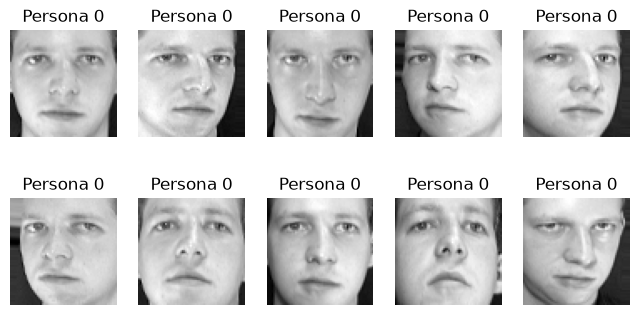

In [15]:
fig, axes = plt.subplots(2,5, figsize=(8,4))

for ax, image, label in zip(
        axes.ravel(),
        faces.images,
        faces.target):

    ax.imshow(image, cmap='gray')
    ax.set_title(f"Persona {label}")
    ax.axis('off')

plt.show()

4. Dividir entrenamiento y prueba

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y

)

### 4.1. Entrenamiento SIN PCA (Modelo con Ruido)
Para entender la importancia del PCA, primero vamos a entrenar los modelos pasándole las imágenes crudas (es decir, las **4096 columnas** enteras llenas de fondo, ropa y ruido). Vamos a medir su exactitud y el tiempo que tarda.

In [17]:
import time
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("=== Entrenamiento SIN PCA (4096 dimensiones) ===")

# KNN sin PCA
start = time.time()
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_knn_raw = knn_raw.predict(X_test)
time_knn_raw = time.time() - start
print(f"KNN Accuracy (Sin PCA): {accuracy_score(y_test, y_pred_knn_raw):.4f} | Tiempo: {time_knn_raw:.4f} seg")

# SVC sin PCA
start = time.time()
svc_raw = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_raw.fit(X_train, y_train)
y_pred_svc_raw = svc_raw.predict(X_test)
time_svc_raw = time.time() - start
print(f"SVC Accuracy (Sin PCA): {accuracy_score(y_test, y_pred_svc_raw):.4f} | Tiempo: {time_svc_raw:.4f} seg")

print("\n¡Atención a estos números! Ahora los compararemos con los resultados DESPUÉS de aplicar PCA.")

=== Entrenamiento SIN PCA (4096 dimensiones) ===
KNN Accuracy (Sin PCA): 0.8700 | Tiempo: 0.9363 seg
SVC Accuracy (Sin PCA): 0.9400 | Tiempo: 0.5795 seg

¡Atención a estos números! Ahora los compararemos con los resultados DESPUÉS de aplicar PCA.


5. Aplicar PCA (Eigenfaces)

In [18]:
pca = PCA(

    n_components=150,
    whiten=True,
    random_state=42

)

X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

6. Visualizar Eigenfaces

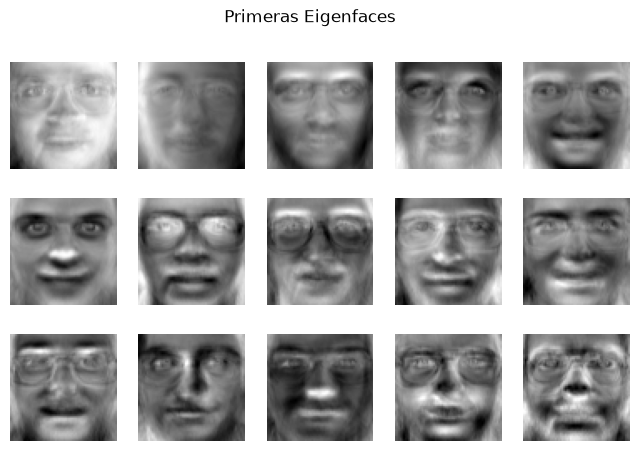

In [19]:
fig, axes = plt.subplots(3,5, figsize=(8,5))

for ax, comp in zip(axes.ravel(), pca.components_):

    ax.imshow(comp.reshape(64,64), cmap='gray')
    ax.axis('off')

plt.suptitle("Primeras Eigenfaces")
plt.show()

7. Entrenar un clasificador

In [20]:
knn = KNeighborsClassifier(

    n_neighbors=3

)

knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](40,)","[ 0, 1, 2,...,37,38,39]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


8. Realizar predicciones

In [21]:
y_pred = knn.predict(X_test_pca)

9. Exactitud

In [22]:
accuracy = accuracy_score(

    y_test,
    y_pred

)

print("Accuracy:", accuracy)

Accuracy: 0.69


10. Reporte

In [23]:
print(classification_report(

    y_test,
    y_pred

))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      0.33      0.50         3
           2       1.00      0.67      0.80         3
           3       1.00      0.33      0.50         3
           4       0.40      1.00      0.57         2
           5       0.60      1.00      0.75         3
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         3
           8       0.50      1.00      0.67         2
           9       0.00      0.00      0.00         2
          10       1.00      0.67      0.80         3
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.20      1.00      0.33         3
          15       1.00      0.50      0.67         2
          16       1.00      0.50      0.67         2
          17       0.50    

/home/epadev/Documents/unap-2026/CognitiveHub/ml_research/Aprendizaje-no-supervisado-reduccion-dimensiones/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/epadev/Documents/unap-2026/CognitiveHub/ml_research/Aprendizaje-no-supervisado-reduccion-dimensiones/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/epadev/Documents/unap-2026/CognitiveHub/ml_research/Aprendizaje-no-supervisado-reduccion-dimensiones/.venv/lib/python3.13/site-packages/sklearn/metr

11. Matriz de confusión

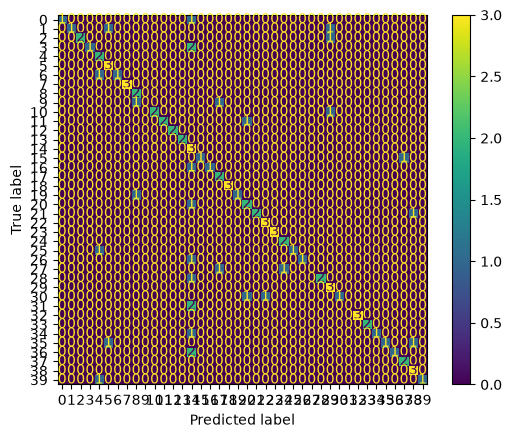

In [24]:
ConfusionMatrixDisplay.from_predictions(

    y_test,
    y_pred

)

plt.show()

### 12. Mejora del modelo usando Support Vector Classifier (SVC)
Aunque KNN logra una exactitud del 69%, podemos mejorar significativamente este resultado utilizando un clasificador más robusto como SVC (Support Vector Classification), el cual se adapta de excelente manera a las Eigenfaces extraídas por PCA sin utilizar redes neuronales.

In [25]:
from sklearn.svm import SVC

# Entrenar modelo SVC
svc = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc.fit(X_train_pca, y_train)

# Predicciones
y_pred_svc = svc.predict(X_test_pca)

# Evaluación
print("Accuracy SVC:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc, zero_division=0))

Accuracy SVC: 0.98
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
        